# 04: Dual-curve pricing

## Objective

Before the 2007-08 money-market dislocation, the market priced a swap off a
single curve. The rate used to forecast a floating coupon was the rate used
to discount it, because both were the same LIBOR quote and nobody could see a
reason to distinguish them. That construction has an elegant consequence: a
floating-rate note indexed to the curve it is discounted on is worth exactly
par on any reset date, whatever the shape of the curve. The identity is
algebraic, not empirical, and it was the backbone of how swaps were quoted
and hedged.

The identity broke because its premise did. In the 2007-08 dislocation,
unsecured interbank term lending froze, and the three-month LIBOR fixing
stopped being a reliable guide to the cost of carrying a collateralised
derivative position. At the same time collateral agreements made the
overnight rate the true financing rate of a derivative position: daily
variation margin is remunerated at the overnight index, so the value of a
collateralised trade is carried at that rate. Forecasting and discounting
became two different questions, and the market answered them with two
different curves.

This notebook works through the consequence in the library's own machinery.
The engine exposes the switch directly: `usd_curveset` builds a discount
curve (OIS) and a forecast curve (3-month Term SOFR) with one reference date,
and a pricer asks for `discount` to discount and `forecast_for("3M")` to
project. Nothing else needs to know that two curves exist. Four questions
follow:

1. How far apart are the OIS and 3-month forecast curves in this snapshot?
2. How much does the discounting choice move the *bootstrapped forecast curve*?
3. How much does it move *prices*: a par swap rate, an off-market swap, a
   floating-rate note?
4. How do those answers scale with the size of the basis, given that the basis
   here is a few basis points and reached roughly 350 basis points in
   October 2008?

The answers are not all the same size, and the difference between them is the
point of the notebook.

## Data

Two committed files feed the USD build, and both need to be described
accurately before any number is read off them.

`usd_ois_swaps.csv` holds SOFR OIS par rates at eight tenors for
24 July 2026. These are **constructed, not observed**. No free and
redistributable source publishes a complete SOFR OIS swap curve, so
`DATA_SOURCES.md` records the construction: each par rate is the FRED
Treasury constant-maturity (CMT) yield at that tenor plus a dated
OIS-minus-Treasury spread taken from a Bloomberg generic quote at the
24 July 2026 close, accurate to roughly ±2 basis points. The CMT yields are
used as **approximate CMT-implied curve inputs**: a labelled model mapping for
this educational pipeline, not a set of raw Treasury security prices and not
an official Treasury bootstrap. The OIS par rates inherit that label.

`usd_forecast_basis.csv` holds the 3-month Term SOFR **minus** SOFR OIS basis
in basis points at eight tenors, indicative mid-market, rounded to the
nearest half basis point. The subtraction order is fixed: the basis is
forecast rate minus OIS rate, so the forecast curve is rebuilt as OIS plus
this basis. CME Term SOFR itself cannot be committed: §2.2 of the CME
Information License Agreement prohibits redistribution of the benchmark
values. The basis file exists so that the repository runs end to end without
a CME licence.

What this means for every result below: the *level* of these curves carries the
authority of the Treasury curve and a cited spread, and the *basis between
them* is representative rather than tradable. Conclusions about mechanism (which
effect exists, what breaks, what the sign is) are reliable. Conclusions
about magnitude inherit the ±2 basis point uncertainty of the inputs. Where
magnitude matters below, the basis is deliberately scaled across a range that
spans the observed post-2008 history, so that no argument rests on the
indicative marks being exactly right.

The two files also disagree about tenors. The OIS file runs to 30 years; the
basis file stops at 10. The forecast build takes the inner join, so the
forecast curve's covered horizon is 10 years (measured below) while the
discount curve is covered to 30 years; beyond its covered horizon the
forecast curve extrapolates flat in the zero rate. All pricing below stays
inside 10 years.

In [1]:
import math
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from yieldcurve.calendars import NullCalendar
from yieldcurve.conventions import BusinessDayConvention, DayCount, add_months, year_fraction
from yieldcurve.curves.bootstrap import Quote, bootstrap, repricing_report
from yieldcurve.curves.build import usd_curveset, usd_ois_curve
from yieldcurve.curves.interpolation import InterpMethod, overlay_curve
from yieldcurve.curves.pricing import annuity, par_rate, price
from yieldcurve.curves.protocol import CurveSet, Fixings, MissingFixingError, curve_time
from yieldcurve.instruments import FRN, Bill, VanillaSwap
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

ois_quotes = snapshot.load("usd_ois_swaps").sort_values("tenor_years")
ois_quotes["tenor_years"] = ois_quotes["tenor_years"].astype(float)
basis_quotes = snapshot.load("usd_forecast_basis").sort_values("tenor_years")

forecast_quotes = ois_quotes.merge(
    basis_quotes, on="tenor_years", how="inner", validate="one_to_one"
)
forecast_quotes["forecast_par"] = forecast_quotes["par_rate"] + forecast_quotes["basis_bp"] / 1e4

print("OIS par rates (constructed CMT-implied inputs) and the 3M basis (indicative)")
print(
    forecast_quotes.assign(
        ois_pct=lambda f: f["par_rate"] * 100,
        forecast_pct=lambda f: f["forecast_par"] * 100,
    )[["tenor_years", "ois_pct", "basis_bp", "forecast_pct"]].to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)
print(
    f"\nOIS tenors {sorted(ois_quotes['tenor_years'])}"
    f"\nbasis tenors {sorted(basis_quotes['tenor_years'])}"
    f"\ninner join -> forecast curve spans "
    f"{forecast_quotes['tenor_years'].min():.0f}Y to "
    f"{forecast_quotes['tenor_years'].max():.0f}Y"
)

OIS par rates (constructed CMT-implied inputs) and the 3M basis (indicative)
 tenor_years  ois_pct  basis_bp  forecast_pct
      1.0000   4.1200    1.5000        4.1350
      2.0000   4.2800    2.0000        4.3000
      3.0000   4.3000    2.5000        4.3250
      5.0000   4.3800    3.0000        4.4100
      7.0000   4.5000    3.5000        4.5350
     10.0000   4.6500    4.0000        4.6900

OIS tenors [1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
basis tenors [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
inner join -> forecast curve spans 1Y to 10Y


## Theory

### Why the discount rate is the collateral rate

The modern justification for OIS discounting is not that the overnight rate is
risk-free. It is that a collateralised derivative is financed at the rate the
collateral earns. Piterbarg's 2010 argument ("Funding beyond discounting:
collateral agreements and derivatives pricing", *Risk*, February 2010) runs as
follows. Under a credit support annex with daily cash variation margin, the
holder of a position with value $V_t$ receives collateral $V_t$ and pays
interest on it at the contractual rate $c_t$, which for a standard cash CSA is
the overnight index. Replicating the payoff therefore costs $c_t$ to carry, not
the dealer's unsecured funding rate, and the value of a payoff $H_T$ is

$$V_t = \mathbb{E}^{Q}_t\!\left[\exp\left(-\int_t^T c_s \, ds\right) H_T\right].$$

The discount curve is a property of the *collateral agreement*, not of the
trade. Two economically identical swaps under two different CSAs have two
different values, which is why CSA discounting became an operational problem
and not just a modelling one.

Central counterparties made this concrete. CME and LCH both moved USD cleared
swap discounting and price alignment from effective fed funds to SOFR in
October 2020, compensating members in cash and basis swaps for the resulting
valuation change. The change of discount curve had a price, and the clearing
houses paid it explicitly.

### Why forecasting needs its own curve

The forecast curve answers a different question: what will 3-month Term SOFR
fix at, one year from now? A term rate embeds the credit and liquidity of
lending for a term, and the overnight index does not. The gap is the tenor
basis. It is not an arbitrage, because capturing it requires funding a term
position with overnight rolls, and the 2007-08 dislocation established exactly
how expensive that can become. Bianchetti (2010, "Two curves, one price") and
Henrard (2007, "The irony in the derivatives discounting") set out the
resulting two-curve framework: project each floating index off a curve
calibrated to instruments on *that* index, discount everything off the
collateral curve.

### The floating-rate note identity

The cleanest diagnostic in this notebook is an algebraic identity. Take a note
paying, at each date $T_i$, the simple forward $L(T_{i-1}, T_i)$ over accrual
$\tau_i$, with the principal repaid at $T_n$. Under the single-curve convention
the forward implied by the discount curve is

$$L(T_{i-1}, T_i) = \frac{1}{\tau_i}\left(\frac{P(T_{i-1})}{P(T_i)} - 1\right),$$

so the present value of coupon $i$ is

$$P(T_i) \, \tau_i \, L(T_{i-1}, T_i) = P(T_{i-1}) - P(T_i).$$

Summing over $i = 1 \dots n$ telescopes to $P(T_0) - P(T_n)$, and adding the
redemption $P(T_n)$ leaves $P(T_0) = 1$. The note is worth par on a reset date
regardless of the level or shape of the curve, because every coupon is
constructed from the same discount factors that value it.

Break the link: project off one curve and discount off another: and the
telescoping fails term by term. The note is no longer worth par, and the size
of the deviation is a direct measurement of the basis. This is used below as a
test of the implementation and as a measurement of the economics.

## Methodology

The experiment uses one set of quotes and two curve sets:

| Build | Projection curve | Discount curve | Convention |
|---|---|---|---|
| `dual` | solved forecast curve | OIS | post-2008 |
| `single` | solved forecast curve | itself | pre-2008 |

Both conventions are built with the **canonical method, log-linear
interpolation of the discount factor** — the same method the public builders
use by default. The dual build goes through the public builder
`usd_curveset`, which bootstraps the 3-month projection curve while
discounting the quoted swaps off OIS. The single build has no public builder:
`usd_forecast_curve` discounts off OIS by construction, so the
self-discounted projection is bootstrapped here with the canonical default
method directly. Because both builds share the canonical interpolation rule,
any difference between them is attributable to the discounting choice and not
to the interpolation rule that notebook 02 measured. The stress rebuilds in
`build_pair` bootstrap both conventions the same way — bare `bootstrap` calls
that fall back to the same canonical default — so the sensitivity table holds
the convention fixed as well.

The notebook's `usd_swap` helper uses the same conventions as the builder,
including the maturity rule: integer-year tenors land on the calendar-month
anniversary, exactly as in `yieldcurve.curves.build`. The parity is not
asserted: the canonical builds below reprice every input quote exactly, and
the measured residual is printed.

Instruments are priced only through `yieldcurve.curves.pricing`; the notebook
constructs contracts and reads results, and computes no cash flow of its own.

In [2]:
def usd_swap(years: float, fixed_rate: float, notional: float = 1_000_000.0) -> VanillaSwap:
    """A 3M-float USD swap on the same conventions the curve builder uses.

    Integer-year tenors mature on the calendar-month anniversary, matching
    ``yieldcurve.curves.build._maturity``; the exact repricing printed below
    verifies the parity.

    The month-grid maturity is assumed: all current basis tenors are
    month-aligned, and a future off-month tenor would need ``_maturity``'s
    ``round(years * 365)``-day fallback instead.
    """
    return VanillaSwap(
        start=ASOF,
        maturity=add_months(ASOF, round(years * 12.0)),
        fixed_rate=fixed_rate,
        fixed_frequency=2,
        fixed_day_count=DayCount.THIRTY_360_BOND,
        float_tenor="3M",
        float_day_count=DayCount.ACT_360,
        calendar=NullCalendar(),
        bdc=BusinessDayConvention.UNADJUSTED,
        notional=notional,
    )


quotes = [
    Quote(instrument=usd_swap(float(years), float(rate)), rate=float(rate))
    for years, rate in zip(
        forecast_quotes["tenor_years"], forecast_quotes["forecast_par"], strict=True
    )
]

ois_curve = usd_ois_curve(snapshot, ASOF)
dual = usd_curveset(snapshot, ASOF)
forecast_curve = dual.forecast_for("3M")
single_curve = bootstrap(quotes, asof=ASOF)
single = CurveSet.single(single_curve)

print(
    f"covered horizons: OIS {ois_curve.covered_horizon:.4f} years, "
    f"forecast {forecast_curve.covered_horizon:.4f} years"
)

rows = []
for t in (0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0):
    z_ois, z_dual, z_single = ois_curve.zero(t), forecast_curve.zero(t), single_curve.zero(t)
    rows.append(
        {
            "t": t,
            "ois_pct": z_ois * 100,
            "forecast_pct": z_dual * 100,
            "single_pct": z_single * 100,
            "fcst_minus_ois_bp": (z_dual - z_ois) * 1e4,
            "dual_minus_single_bp": (z_dual - z_single) * 1e4,
        }
    )
zeros = pd.DataFrame(rows)
print("\nzero rates in % per annum (continuous compounding); spreads in basis points")
print(zeros.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

covered horizons: OIS 30.0219 years, forecast 10.0082 years

zero rates in % per annum (continuous compounding); spreads in basis points
        t  ois_pct  forecast_pct  single_pct  fcst_minus_ois_bp  dual_minus_single_bp
 0.500000 4.092332      4.092491    4.092490           0.015904              0.000082
 1.000000 4.092332      4.092491    4.092490           0.015904              0.000082
 2.000000 4.250964      4.251594    4.251591           0.062982              0.000275
 3.000000 4.270367      4.278093    4.278054           0.772576              0.003884
 5.000000 4.352231      4.367197    4.367142           1.496629              0.005479
 7.000000 4.480807      4.501049    4.501046           2.024227              0.000378
10.000000 4.647791      4.674803    4.674945           2.701235             -0.014230


## Result 1: the basis is in the curve; the discounting choice is not

Two columns of that table say different things.

`fcst_minus_ois_bp` is the term basis expressed as a zero-rate spread. It
widens monotonically with maturity, from 0.016 basis points at six months to
2.70 basis points at ten years, which is the shape one expects when the
quoted basis itself widens from 1.5 to 4 basis points across the same range.
The forecast curve sits above OIS everywhere. Nothing here is surprising, and
nothing here depends on the discounting convention.

`dual_minus_single_bp` is the interesting column, and it is almost empty. The
largest entry in absolute terms is -0.0142 basis points at ten years; at six
months and one year the two builds agree to within a ten-thousandth of a basis
point. Changing the discount curve from the forecast curve to OIS moves the
*bootstrapped forecast curve* by around a hundredth of a basis point.

That is not a bug, and it is worth understanding why, because it is the single
most common source of confusion about what dual-curve construction actually
does. A par swap has zero value: the fixed leg present value equals the
floating leg present value. Both legs are discounted on the same curve, so
scaling all discount factors by a common factor leaves the equality intact. The
par rate is close to invariant to the discount curve, and a bootstrap that
solves for a projection curve from par quotes therefore recovers nearly the
same projection curve whichever discount curve it uses. The residual
hundredths of a basis point come from the discount factors reweighting
individual accrual periods within the leg, not from any first-order effect.

The corollary matters for anyone who has been told that dual-curve
bootstrapping "changes the curve": measured on this snapshot, it does not, to
any degree a market participant would notice.

par swap rates in % per annum; spreads in basis points
    tenor  quoted_pct  dual_pct  single_pct  dual_minus_single_bp  dual_minus_quoted_bp
 1.000000    4.135000  4.135000    4.135000              0.000000              0.000000
 2.000000    4.300000  4.300000    4.300000              0.000000              0.000000
 3.000000    4.325000  4.325000    4.325000              0.000000              0.000000
 5.000000    4.410000  4.410000    4.410000              0.000000              0.000000
 7.000000    4.535000  4.535000    4.535000              0.000000             -0.000000
10.000000    4.690000  4.690000    4.690000             -0.000000             -0.000000

max |dual - single| par rate over the six pillars: 5.343e-12 bp

max |par rate - quote| over the six pillars, by construction
  canonical log-linear (builder): 4.649e-16
  overlay CUBIC_LOG_DF     0.1537 bp
  overlay MONOTONE_CONVEX  0.1547 bp


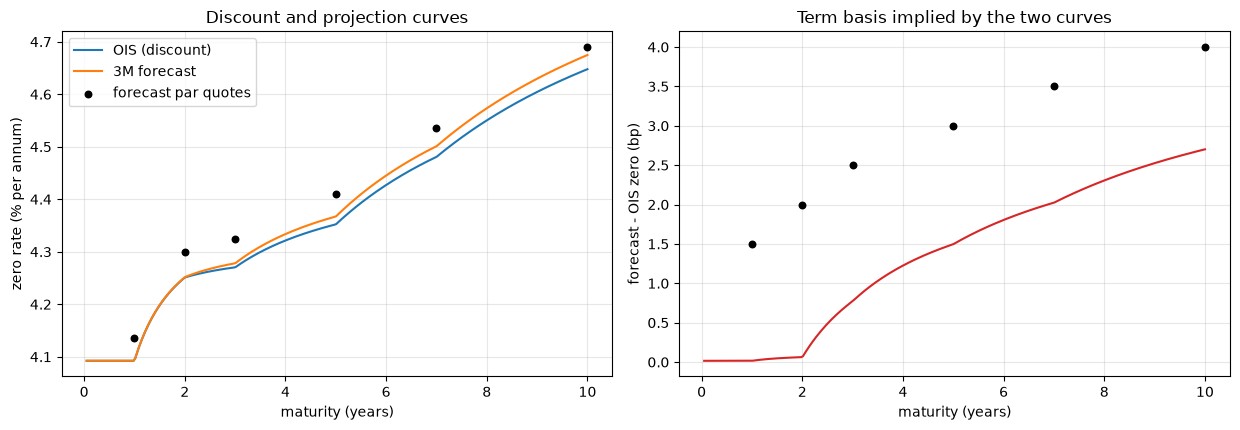

In [3]:
par_rows = []
for years in (1.0, 2.0, 3.0, 5.0, 7.0, 10.0):
    contract = usd_swap(years, 0.0)
    p_dual = par_rate(contract, dual, ASOF)
    p_single = par_rate(contract, single, ASOF)
    quoted = forecast_quotes.loc[forecast_quotes["tenor_years"] == years, "forecast_par"]
    par_rows.append(
        {
            "tenor": years,
            "quoted_pct": float(quoted.iloc[0]) * 100 if len(quoted) else np.nan,
            "dual_pct": p_dual * 100,
            "single_pct": p_single * 100,
            "dual_minus_single_bp": (p_dual - p_single) * 1e4,
            "dual_minus_quoted_bp": (p_dual - float(quoted.iloc[0])) * 1e4
            if len(quoted)
            else np.nan,
        }
    )
print("par swap rates in % per annum; spreads in basis points")
print(pd.DataFrame(par_rows).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
par_gap_bp = max(
    abs(p_dual - p_single) * 1e4
    for years in (1.0, 2.0, 3.0, 5.0, 7.0, 10.0)
    for p_dual, p_single in [
        (par_rate(usd_swap(years, 0.0), dual, ASOF), par_rate(usd_swap(years, 0.0), single, ASOF))
    ]
)
print(f"\nmax |dual - single| par rate over the six pillars: {par_gap_bp:.3e} bp")

# The residuals above are a property of the interpolation rule, not of dual-curve
# pricing. The canonical build reprices its quotes exactly; the comparative
# overlays are re-interpolations of the same nodes whose final residuals are
# measured, exactly as in notebook 02.
report = repricing_report(forecast_curve, quotes, ASOF, discount_curve=ois_curve)
print(
    "\nmax |par rate - quote| over the six pillars, by construction\n"
    f"  canonical log-linear (builder): {max(abs(r.residual) for r in report):.3e}"
)
for method in (InterpMethod.CUBIC_LOG_DF, InterpMethod.MONOTONE_CONVEX):
    overlay = overlay_curve(forecast_curve, method)
    rebuilt = CurveSet(discount=ois_curve, forecast={"3M": overlay})
    worst = max(
        abs(par_rate(usd_swap(float(y), 0.0), rebuilt, ASOF) - float(r)) * 1e4
        for y, r in zip(
            forecast_quotes["tenor_years"], forecast_quotes["forecast_par"], strict=True
        )
    )
    print(f"  overlay {method.name:<16} {worst:.4f} bp")

grid = np.linspace(0.05, 10.0, 300)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(grid, [ois_curve.zero(t) * 100 for t in grid], label="OIS (discount)")
axes[0].plot(grid, [forecast_curve.zero(t) * 100 for t in grid], label="3M forecast")
axes[0].scatter(
    forecast_quotes["tenor_years"],
    forecast_quotes["forecast_par"] * 100,
    s=22,
    zorder=3,
    color="k",
    label="forecast par quotes",
)
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("zero rate (% per annum)")
axes[0].set_title("Discount and projection curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    grid,
    [(forecast_curve.zero(t) - ois_curve.zero(t)) * 1e4 for t in grid],
    color="C3",
)
axes[1].scatter(
    forecast_quotes["tenor_years"], forecast_quotes["basis_bp"], s=22, zorder=3, color="k"
)
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylabel("forecast - OIS zero (bp)")
axes[1].set_title("Term basis implied by the two curves")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Result 2: the two conventions agree with each other, and the reason is
not the interpolation rule

Two separate things are worth reading off the par-rate table. The first is the
comparison the experiment was built for: at the six quoted pillars the
OIS-discounted and self-discounted builds return par rates that agree to
machine precision — the largest gap over the six pillars is about
$10^{-12}$ basis points. On this dataset the choice of discount curve inside
the bootstrap does not move the par swap rate.

The second is that the canonical builds reprice their own input quotes
exactly: the largest quote residual in the repricing report is below
$10^{-15}$, and the exactness is part of the builder's contract rather than a
coincidence. The repricing report and the par table above both cover the
six-pillar grid, so the two objects are the same six input quotes. The
maturity rule matters here: the notebook's `usd_swap` helper
uses the same calendar-month maturity rule as `yieldcurve.curves.build`, so
the repricing check is apples to apples. This is the canonical property
notebook 01 described: log-linear interpolation is *local*, so once the
bootstrap has solved a pillar, that interval is fixed for good and later
solves never disturb it.

The interpolation comparison printed under the table isolates the rule's
contribution. Re-interpolating the canonical forecast nodes with a cubic
log-DF or a monotone-convex overlay leaves measured residuals of up to about
0.15 basis points — the same order notebook 02 measured on the SEK curve.
Those overlays are *non-local*: the curve inside one interval is shaped by the
discrete forwards on neighbouring intervals, so a bond whose coupons fall
between pillars no longer reprices exactly. The residual is a property of the
overlay, not of dual-curve pricing, and the canonical build is the one whose
quotes reprice exactly.

The black dots in the left panel confirm the same thing visually: the forecast
curve passes through its par quotes, and the OIS curve sits below it by an
amount that grows with maturity. The right panel plots the implied zero-rate
basis against the quoted par basis. The two are not the same object: one is a
spread between zero rates, the other a spread between par swap rates: and the
zero basis runs below the par basis at the short end and converges toward it
further out, which is the usual relationship between a spread on par rates and
the spread on the zero curve that supports them.

So far the two conventions look interchangeable. They are not, and the next
experiment shows where the difference actually lives.

In [4]:
FRN_YEARS = 5.0
note = FRN(
    issue=ASOF,
    maturity=add_months(ASOF, round(FRN_YEARS * 12.0)),
    frequency=4,
    day_count=DayCount.ACT_360,
    calendar=NullCalendar(),
    bdc=BusinessDayConvention.UNADJUSTED,
    index_tenor="3M",
    spread=0.0,
)

dual_price = price(note, dual, ASOF)
single_price = price(note, single, ASOF)
project_only = CurveSet(discount=forecast_curve, forecast={"3M": forecast_curve})

print(f"5Y quarterly FRN, zero spread, 3M index, face 100, as of {ASOF}")
print(f"  single curve   (project fcst, discount fcst) : {single_price.dirty:12.8f}")
self_discount = price(note, project_only, ASOF)
print(f"  self-discount  (project fcst, discount fcst) : {self_discount.dirty:12.8f}")
print(f"  dual curve     (project fcst, discount OIS)  : {dual_price.dirty:12.8f}")
print(f"  premium to par under dual curve             : {dual_price.dirty - 100.0:+12.8f}")

5Y quarterly FRN, zero spread, 3M index, face 100, as of 2026-07-24
  single curve   (project fcst, discount fcst) : 100.00000000
  self-discount  (project fcst, discount fcst) : 100.00000000
  dual curve     (project fcst, discount OIS)  : 100.06477607
  premium to par under dual curve             :  +0.06477607


## Result 3: the par identity holds exactly, and then it breaks

Under the single-curve convention the note prices at 100.00000000. Not
approximately: the printed value is par to eight decimal places, and the
underlying float is within one part in $10^{15}$ of 100. That is the
telescoping sum from the theory section, evaluated numerically. It is also a
genuine test of the implementation: day-count handling, schedule generation,
the simple-forward formula and the discounting all have to be mutually
consistent for the cancellation to be exact, and a single misaligned accrual
factor would show up in the sixth decimal place.

The middle line makes the attribution airtight. Projecting off the forecast
curve and discounting off the *same* forecast curve also returns par. So the
identity does not depend on which curve is used, only on the two curves being
the same one.

Under the dual-curve convention the same note is worth 100.06477607, a premium
of 6.48 cents per 100 of face. The sign is the one the economics requires: the
coupons are projected off a curve that lies above the discount curve, so the
note pays a stream slightly richer than the rate at which that stream is
financed, and it must trade above par to compensate. A five-year note carrying
a two-to-four basis point pickup for five years is worth roughly six basis
points of price, which is what the number says.

This is the whole of dual-curve pricing in one line. The curves barely moved.
The price did.

## Delayed valuation: the discount-ratio convention and an active coupon

Every price so far has been struck on the curve reference date, 24 July 2026.
The library's pricing paths are defined for any valuation date: a cash flow at
$T$ valued at $a$ is discounted with the reference-date ratio

$$\operatorname{DF}(a, T) = \frac{D_r(T)}{D_r(a)},$$

where $D_r$ is the discount curve as a function of absolute curve time from
the reference date $r$. On a *non-flat* curve the ratio is neither of the
tempting shortcuts: it is not $\exp(-z(T)\,(T-a))$, applying the zero rate at
$T$ over the interval, and it is not $D_r(T)$, the reference-date discount
factor. Both would misprice a delayed valuation.

A zero-coupon claim (a `Bill`) is the purest check: its delayed price must
equal $D_r(T)/D_r(a)$ exactly. A floating-rate note valued three days after a
reset date exercises the second contract: the coupon that has already fixed
must be paid from an observed **fixing**, not projected as a forward over a
stub. The library raises `MissingFixingError` when the observed rate is
absent; it never replaces a missing fixing with a shortened forward.

In [5]:
# The discount-ratio convention, on a non-flat curve. r = ASOF; the OIS zero
# rate moves from 4.09% at one year to 4.25% at two years, so the interval
# [a, T] spans a genuinely changing rate and the ratio is not the naive
# single-rate discount.
bill = Bill(maturity=date(2028, 7, 24), face=100.0)
a = date(2027, 7, 27)  # delayed valuation date, one year and three days after r
t_bill = curve_time(ASOF, bill.maturity)
t_a = curve_time(ASOF, a)
p_bill = price(bill, dual, a).dirty
ratio = 100.0 * ois_curve.df(t_bill) / ois_curve.df(t_a)
naive = 100.0 * math.exp(-ois_curve.zero(t_bill) * (t_bill - t_a))
ref_df = 100.0 * ois_curve.df(t_bill)

print("Zero-coupon claim, face 100, maturity 2028-07-24, valued 2027-07-27")
print(f"  price at the delayed date        : {p_bill:.10f}")
print(f"  D_r(T) / D_r(a) * 100            : {ratio:.10f}")
print(f"  naive exp(-z(T)(T-a)) * 100      : {naive:.10f}")
print(f"  reference-date D_r(T) * 100      : {ref_df:.10f}")
print(
    f"  zero rate at T / at a            : {100 * ois_curve.zero(t_bill):.4f}% / "
    f"{100 * ois_curve.zero(t_a):.4f}%"
)

# The FRN three days after the 2027-07-24 reset: the active coupon
# [2027-07-24, 2027-10-24] has already fixed; every later coupon is a forward.
dates = note.coupon_dates()
a2 = date(2027, 7, 27)
reset = max(d for d in dates if d < a2)
next_payment = min(d for d in dates if d > a2)
tau_active = year_fraction(reset, next_payment, DayCount.ACT_360)
# The observed reset rate. The frozen snapshot holds no future Term SOFR prints,
# so the fixing is taken as the forecast curve's own forward at the reset date —
# reproducible from the printed discount factors — and a real valuation would
# read the published fixing here instead.
fixing = (
    forecast_curve.df(curve_time(ASOF, reset)) / forecast_curve.df(curve_time(ASOF, next_payment))
    - 1.0
) / tau_active
fixings = Fixings(term={("3M", reset): fixing})

frn_delayed_single = price(note, CurveSet.single(forecast_curve), a2, fixings=fixings)
frn_delayed_dual = price(note, dual, a2, fixings=fixings)
carry = 100.0 * forecast_curve.df(curve_time(ASOF, reset)) / forecast_curve.df(curve_time(ASOF, a2))
accrued_hand = 100.0 * fixing * year_fraction(reset, a2, DayCount.ACT_360)
df_active = ois_curve.df(curve_time(ASOF, next_payment)) / ois_curve.df(curve_time(ASOF, a2))
active_pv = 100.0 * fixing * tau_active * df_active

print(f"\n5Y FRN, 3M index, valued {a2} (three days after the {reset} reset)")
print(f"  active period [{reset}, {next_payment}], ACT/360 accrual {tau_active:.6f}")
print(f"  reset fixing (3M @ {reset}) {fixing:.8f} = {100 * fixing:.4f}%")
print(f"  single curve: dirty {frn_delayed_single.dirty:.10f}")
print(f"    par rolled by D_r(t)/D_r(a): {carry:.10f}")
print(
    f"    clean {frn_delayed_single.clean:.10f}, "
    f"accrued {frn_delayed_single.accrued:.10f} (by hand {accrued_hand:.10f})"
)
print(f"  dual curve: dirty {frn_delayed_dual.dirty:.10f}, clean {frn_delayed_dual.clean:.10f}")
print(
    f"    active coupon PV by hand: {active_pv:.10f} "
    f"(coupon {100 * fixing * tau_active:.8f} x DF {df_active:.10f})"
)
try:
    price(note, dual, a2)
    print("  ERROR: expected MissingFixingError")
except MissingFixingError as exc:
    print(f"  without fixings: {exc}")

Zero-coupon claim, face 100, maturity 2028-07-24, valued 2027-07-27
  price at the delayed date        : 95.7093365273
  D_r(T) / D_r(a) * 100            : 95.7093365273
  naive exp(-z(T)(T-a)) * 100      : 95.8602420907
  reference-date D_r(T) * 100      : 91.8383621660
  zero rate at T / at a            : 4.2512% / 4.0949%

5Y FRN, 3M index, valued 2027-07-27 (three days after the 2027-07-24 reset)
  active period [2027-07-24, 2027-10-24], ACT/360 accrual 0.255556
  reset fixing (3M @ 2027-07-24) 0.04374547 = 4.3745%
  single curve: dirty 100.0362588674
    par rolled by D_r(t)/D_r(a): 100.0362588674
    clean 99.9998043080, accrued 0.0364545595 (by hand 0.0364545595)
  dual curve: dirty 100.1035929543, clean 100.0671383948
    active coupon PV by hand: 1.1059839422 (coupon 1.11793982 x DF 0.9893054339)
  without fixings: 'missing term fixing for 3M @ 2027-07-24'


## Reading the delayed valuation

The zero-coupon check lands exactly: the delayed price is
$D_r(T)/D_r(a) \times 100$ to ten decimals. The two shortcuts are both wrong
on this non-flat curve. The reference-date discount factor $D_r(T)$ gives
91.838, the price one would report by ignoring the valuation date; the
delayed price of 95.709 is $D_r(T)$ renormalised by $1/D_r(a)$, which is the
compounding the position earned between $r$ and $a$. The naive single-rate
discount, applying the two-year zero rate of 4.25% across the whole
interval, gives 95.860 — 15.09 cents too high, because it revalues the year
already lived at the *terminal* rate instead of the 4.09% that actually
prevailed at $a$. The ratio convention is the only one of the three that is
consistent with the curve's own forwards.

The FRN check exercises the fixing contract. The active coupon over
[2027-07-24, 2027-10-24] is paid at the observed reset rate of 4.3745% —
not at a forward projected from the valuation date — and the printed accrued
interest of 0.03645 per 100 of face is reproduced by hand from the fixing.
Under the single-curve convention, where the fixing happens to equal the
forecast curve's own forward at the reset date, the note is worth par on the
reset date and three days later its dirty price is exactly par rolled at the
discount ratio $D_r(t)/D_r(a)$: 100.0362588674 in the printout, matching the
ratio to the last digit. Under the dual convention the same note is worth
100.1036: the active coupon contributes 1.10598 (coupon amount 1.11794 times
the OIS discount ratio 0.98931, printed above), and the future coupons
project off the forecast curve while discounting off OIS.

Finally, the contract's error semantics: dropping the `Fixings` object raises
`MissingFixingError` — the library refuses to guess the active coupon rather
than silently pricing it with a stub forward that would bleed value as the
valuation date advances.

In [6]:
def build_pair(scale: float) -> tuple[CurveSet, CurveSet]:
    """Rebuild both conventions with the quoted basis multiplied by ``scale``."""
    scaled = forecast_quotes["par_rate"] + forecast_quotes["basis_bp"] * scale / 1e4
    scaled_quotes = [
        Quote(instrument=usd_swap(float(years), float(rate)), rate=float(rate))
        for years, rate in zip(forecast_quotes["tenor_years"], scaled, strict=True)
    ]
    projection = bootstrap(scaled_quotes, asof=ASOF, discount_curve=ois_curve)
    self_discounted = bootstrap(scaled_quotes, asof=ASOF)
    return (
        CurveSet(discount=ois_curve, forecast={"3M": projection}),
        CurveSet.single(self_discounted),
    )


payer = usd_swap(7.0, 0.040, notional=10_000_000.0)
stress_rows = []
for scale in (1.0, 5.0, 10.0, 25.0, 50.0, 87.5):
    stressed_dual, stressed_single = build_pair(scale)
    frn_dual = price(note, stressed_dual, ASOF).dirty
    frn_single = price(note, stressed_single, ASOF).dirty
    swap_dual = price(payer, stressed_dual, ASOF).dirty
    swap_single = price(payer, stressed_single, ASOF).dirty
    stress_rows.append(
        {
            "basis_x": scale,
            "basis_10y_bp": 4.0 * scale,
            "frn_dual": frn_dual,
            "frn_single": frn_single,
            "frn_premium": frn_dual - frn_single,
            "swap_dual": swap_dual,
            "swap_single": swap_single,
            "swap_diff": swap_dual - swap_single,
        }
    )
stress = pd.DataFrame(stress_rows)
print("5Y FRN (face USD 100) and 7Y payer swap at fixed rate 4.00% on USD 10,000,000 notional")
print("prices in USD per 100 of face (FRN) and USD (swap); basis in basis points")
print(stress.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

5Y FRN (face USD 100) and 7Y payer swap at fixed rate 4.00% on USD 10,000,000 notional
prices in USD per 100 of face (FRN) and USD (swap); basis in basis points


 basis_x  basis_10y_bp  frn_dual  frn_single  frn_premium      swap_dual    swap_single    swap_diff
  1.0000        4.0000  100.0648    100.0000       0.0648   319,214.8328   319,062.7836     152.0492
  5.0000       20.0000  100.5989    100.0000       0.5989   402,747.6862   400,889.0969   1,858.5893
 10.0000       40.0000  101.2667    100.0000       1.2667   507,163.7530   502,216.5975   4,947.1555
 25.0000      100.0000  103.2698    100.0000       3.2698   820,411.9534   799,938.5708  20,473.3827
 50.0000      200.0000  106.6084    100.0000       6.6084 1,342,492.2875 1,275,934.4280  66,557.8594
 87.5000      350.0000  111.6163    100.0000      11.6163 2,125,612.7885 1,945,113.4229 180,499.3656


## Methodology note on the stress

The last table rebuilds both curve sets six times with the quoted 3-month basis
multiplied by a constant factor, leaving the OIS curve untouched. The largest
factor, 87.5, puts the 10-year basis at 350 basis points, which is the order of
magnitude 3-month USD LIBOR-OIS reached in October 2008. The intermediate
factors span the range that separates a calm market from a stressed one.

This is a controlled sensitivity, not a historical reconstruction. In 2008 the
OIS curve moved too, the basis term structure inverted rather than scaling
proportionally, and the instruments in question were LIBOR-indexed rather than
Term SOFR-indexed. What the exercise establishes is how the *pricing* effect
scales with the *size* of the basis, which is the question the indicative marks
in this snapshot cannot answer on their own.

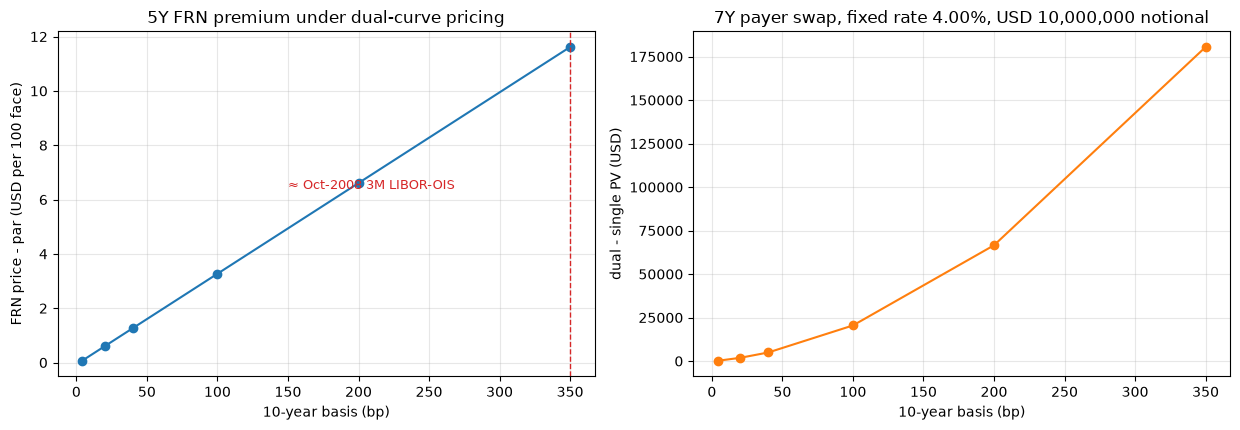

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(stress["basis_10y_bp"], stress["frn_premium"], marker="o")
axes[0].set_xlabel("10-year basis (bp)")
axes[0].set_ylabel("FRN price - par (USD per 100 face)")
axes[0].set_title("5Y FRN premium under dual-curve pricing")
axes[0].grid(alpha=0.3)
axes[0].axvline(350, color="C3", linestyle="--", linewidth=1)
axes[0].annotate(
    "≈ Oct-2008 3M LIBOR-OIS",
    xy=(350, stress["frn_premium"].iloc[-1]),
    xytext=(150, stress["frn_premium"].iloc[-1] * 0.55),
    fontsize=9,
    color="C3",
)

axes[1].plot(stress["basis_10y_bp"], stress["swap_diff"], marker="o", color="C1")
axes[1].set_xlabel("10-year basis (bp)")
axes[1].set_ylabel("dual - single PV (USD)")
axes[1].set_title("7Y payer swap, fixed rate 4.00%, USD 10,000,000 notional")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [8]:
mixed = CurveSet(discount=single_curve, forecast={"3M": forecast_curve})
pv_dual = price(payer, dual, ASOF).dirty
pv_single = price(payer, single, ASOF).dirty
pv_mixed = price(payer, mixed, ASOF).dirty
par_dual = par_rate(payer, dual, ASOF)
par_single = par_rate(payer, single, ASOF)

print(
    "7Y payer swap, fixed rate 4.00%, USD 10,000,000 notional — attribution of the dual/single gap"
)
print(f"  single  (project single, discount single) : {pv_single:14,.2f}")
print(f"  mixed   (project fcst,   discount single) : {pv_mixed:14,.2f}")
print(f"  dual    (project fcst,   discount OIS)    : {pv_dual:14,.2f}")
print(f"  projection effect : {pv_mixed - pv_single:+10,.2f}")
print(f"  discounting effect: {pv_dual - pv_mixed:+10,.2f}")
print(f"  total             : {pv_dual - pv_single:+10,.2f}")
print()
print(f"  annuity, dual   : {annuity(payer, dual, ASOF):.10f}  (per unit notional)")
print(f"  annuity, single : {annuity(payer, single, ASOF):.10f}  (per unit notional)")
print(f"  par rate, dual  : {par_dual * 100:.6f}%")
print(f"  par rate, single: {par_single * 100:.6f}%")
print(f"  payer fixed rate 4.00% sits {1e4 * (par_dual - 0.040):.1f} bp below the dual par rate")

7Y payer swap, fixed rate 4.00%, USD 10,000,000 notional — attribution of the dual/single gap
  single  (project single, discount single) :     319,062.78
  mixed   (project fcst,   discount single) :     319,067.53
  dual    (project fcst,   discount OIS)    :     319,214.83
  projection effect :      +4.75
  discounting effect:    +147.30
  total             :    +152.05

  annuity, dual   : 5.9666323887  (per unit notional)
  annuity, single : 5.9637903483  (per unit notional)
  par rate, dual  : 4.535000%
  par rate, single: 4.535000%
  payer fixed rate 4.00% sits 53.5 bp below the dual par rate


## Result 4: where the money is, and where it is not

The stress table separates two behaviours cleanly.

The floating-rate note under the single-curve convention prices at exactly
100.0000 in every row, at a 4 basis point basis and at a 350 basis point
basis alike. The identity is algebraic and knows nothing about the size of the
spread. Under the dual-curve convention the premium grows from 6.48 cents to
11.62 per 100 of face, close to linearly in the basis: at 20 basis points the
premium is 0.5989, and at 200 basis points it is 6.6084, an eleven-fold
increase for a ten-fold increase in the basis. The mild convexity comes from
the projected coupons and the discount factors both responding to the wider
spread.

The 7-year payer swap is struck at a fixed rate of 4.00%, 53.5 basis points
below its dual-curve par rate of 4.5350%. It is worth 319,214.83 under the
dual-curve convention and 319,062.78 under the single, a gap of 152.05 on a
10 million notional: about 0.15 basis points of notional. At a 350 basis
point basis the same comparison is 2,125,612.79 against 1,945,113.42, a gap
of 180,499.37: about nine per cent of the single-curve value of the
position. The valuation difference between the two conventions on a single
mid-size swap moves from USD 152 in a calm market to USD 180,499 at
crisis-scale basis.

The attribution cell splits that gap for the base case. Holding the projection
curve fixed at the dual-curve forecast curve and changing only the discount
curve accounts for +147.30 of the +152.05 total. Changing the projection curve
accounts for +4.75. The dual-curve effect on this instrument is a discounting
effect almost in its entirety, which follows directly from Result 1: the two
bootstraps produced nearly the same projection curve, so almost nothing is left
for the projection channel to contribute.

The annuity figures show the mechanism. Discounting off OIS gives 5.96663
per unit notional against 5.96379 off the forecast curve, a difference of
0.00284 or 4.8 basis points of the annuity. OIS discount factors are larger
because OIS rates are lower, so every fixed-leg cash flow is worth marginally
more, and an off-market swap with a non-zero net position is revalued by
roughly that fraction. The par rates, by contrast, agree to machine precision:
the numerator and the denominator both scale, and the ratio does not.

This is the practical summary of the experiment. **Dual-curve construction
leaves par rates alone and revalues everything that is not at par.** New trades
are struck at essentially the same level under either convention. The existing
book, the collateral call, the day-one profit on an off-market novation and the
valuation of a floating-rate asset all move.

## Interpretation of results

**The basis lives in discounting, not projection.** Result 1 shows that the
choice of discount curve during bootstrap has negligible impact on the forecast
curve: with OIS as the discount curve, the 3-month projection curve differs
from the self-discounted forecast by at most 0.014 basis points at 10 years.
The basis spread between OIS and the forecasting index is not expressed by
adding a curve; it is expressed by changing which existing curve is used for
discounting. This structural insight explains why the dual-curve framework
can be so compact: the OIS curve is already in the market data; nothing needs
to be invented or calibrated.

**Par instruments are invariant to the choice.** Result 2 and Result 3
together establish an invariance that is exact rather than approximate. Par
swap rates computed under the single-curve convention agree with those
computed under dual-curve pricing to machine precision across the 1- to
10-year pillars — the largest measured gap is about $10^{-12}$ basis points.
New swap trades, struck at the market par rate, have identical value under
both conventions. The annuity, meaning the present value per unit of fixed
leg, differs by 0.00284 (5.96663 dual against 5.96379 single), about 4.8 basis
points of its own size. But the annuity is the denominator. Both numerator and
denominator scale with the discount curve, leaving their ratio nearly
unchanged. This is not a coincidence; it is an identity: a par instrument has
zero net present value by definition, and both conventions price it that way.

**Non-par instruments revalue by the discounting channel.** Result 3 and
Result 4 show where the dual-curve effect actually lives. A 5-year
floating-rate note at zero spread prices at exactly 100.0000 under the
single-curve convention (the telescoping sum, true to machine precision) and
at 100.0648 under dual-curve pricing: a premium of 6.48 cents per 100 face.
The coupons are projected off a curve that lies above the discount curve (by
the basis), so the note receives cash flows worth more than the discount curve
alone would suggest. Under Result 4, a 7-year payer swap struck 53.5 basis
points below its par rate differs by 152.05 on 10 million notional (0.15
basis points of notional), of which 147.30 comes from discounting and 4.75
from projection. The discounting channel dominates because the projection
curves are nearly identical (Result 1).

**The effect scales linearly with basis and becomes material in stress.**
Result 4's stress experiment rebuilds both curve sets at basis multiples from
1x to 87.5x, corresponding to a 4 basis point basis (current) to a 350 basis
point basis (October 2008 order of magnitude). The FRN premium grows from 6.48
cents to 11.62 per 100 face, roughly proportional to the basis. The swap
valuation gap grows from 152.05 to 180,499.37: a gap that was USD 152 in a
calm market becomes about nine per cent of the position's value in stress.
The magnitudes illustrate why the market changed the convention: the dual-curve
effect is measured in hundreds of dollars in normal times and in hundreds of
thousands on a single mid-size swap in a crisis.

## Regulation and market convention

**IFRS 13, fair value measurement.** Fair value is an exit price using the
assumptions market participants would use. Once the interdealer market
discounted collateralised swaps off the overnight index, a bank still
discounting off LIBOR was not measuring an exit price, and the choice of
discount curve became an audit matter rather than a modelling preference. The
quoted pillars here are observable market rates; the interpolated and
extrapolated regions are unobservable inputs — a Level 3 input in IFRS 13
terms, whose hierarchy classification follows the significance of the
lowest-level significant input (IFRS 13.72-74). No automatic classification of
any measurement follows from that: this notebook performs no entity-level
fair-value measurement. The basis file in this repository is indicative rather
than observable, which is the honest reading of its status.

**Central clearing and the discounting switch.** CME and LCH moved USD cleared
swap discounting and price alignment interest from effective fed funds to SOFR
in October 2020. Because the change altered the value of every cleared
position, both houses ran a compensation mechanism: a cash payment for the
valuation change plus basis swaps to neutralise the resulting risk. The
episode is the clearest available demonstration that the discount curve is
itself a priced object.

**Benchmark reform.** The FCA announced on 5 March 2021 that it would stop
compelling panel-bank LIBOR submissions, and the main USD LIBOR settings
ceased representative publication after 30 June 2023. The ISDA 2020 IBOR
Fallbacks Supplement and Protocol, effective 25 January 2021, hard-wired
fallbacks to compounded risk-free rates plus a fixed spread adjustment set
from the five-year median LIBOR-RFR spread. In the EU the Benchmarks
Regulation (Regulation (EU) 2016/1011) supplies the statutory framework. The
tenor basis did not disappear with LIBOR: CME Term SOFR is a forward-looking
term rate derived from SOFR futures, and the basis measured in this notebook
is the spread between that term rate and compounded overnight SOFR.

**CRR Article 105 and prudent valuation.** Under Regulation (EU) No 575/2013
Article 105, institutions must hold additional valuation adjustments where the
market prices of the positions they hold are uncertain. That is an
institution-level obligation on positions an institution actually holds. The
sensitivity table above measures how the dual-curve gap scales with the size
of the basis; it is an educational exhibit, not an AVA calculation, and no
capital treatment is implied by anything in this repository.

**Discount and forecast curves: a stated convention.** This notebook follows
the market convention of discounting collateralised cash flows off the
overnight index and projecting the floating index off its own term curve. That
mapping — risk-free overnight for discounting, commercial term margin for
forecasting — is the convention the notebook adopts and documents; it is an
industry practice, not a prescription of any single supervisory standard.
Notebook 05 takes the dual-curve `CurveSet` built here and measures its risk
under the repository's EU 2024/856 scenario framework.

## Limitations

The OIS par rates are constructed from Treasury CMT yields plus a dated spread
and carry roughly ±2 basis points of uncertainty. The forecast basis is
indicative and rounded to half a basis point. Neither is a tradable mark, and
no statement in this notebook should be read as a claim about the level of the
USD swap market on 24 July 2026.

The stress scales the basis proportionally at every tenor. Real basis stress
does not behave that way: in 2008 the short end blew out far more than the long
end, so a proportional scaling understates the front-end effect and overstates
the tail. The exercise measures the sensitivity of the pricing gap to the size
of the basis, and nothing more.

Only one floating index is modelled. A full multi-curve framework carries a
separate projection curve for each tenor: 1M, 3M, 6M, 12M: calibrated jointly
to tenor basis swaps, and the consistency conditions between them are a
substantial part of a full multi-curve implementation. The `CurveSet` type
here supports a dictionary of tenors and this snapshot populates one of them.

Discounting is single-currency and assumes a standard cash CSA remunerated at
the overnight index. Cross-currency collateral, non-cash collateral, thresholds
and one-way agreements each change the discount curve, and none of that is
modelled. Nor are the valuation adjustments: CVA, DVA, FVA, ColVA: that sit
on top of a collateralised value.

The forecast curve stops at 10 years because the basis file does. Pricing a
3-month-indexed instrument beyond that would extrapolate the projection curve
against a discount curve that has genuine 20 and 30-year quotes, and the
results would say more about the extrapolation than about the market.

## Summary

Splitting the forecast curve from the discount curve is the defining structural
change in post-2008 interest rate pricing, and this notebook measures what the
split is worth on a real curve build.

The bootstrapped forecast curve is almost indifferent to the choice: switching
the discount curve from self-discounting to OIS moves the ten-year forecast
zero rate by 0.014 basis points, and moves par swap rates by less than
$10^{-11}$ basis points. Par instruments are close to invariant because both
legs scale with the discount factors.

Prices of non-par instruments are not indifferent. A five-year floating-rate
note at zero spread prices at exactly 100.00000000 under the single-curve
convention: the telescoping identity, confirmed to machine precision, which
doubles as a test that the schedule, day-count and forward conventions in the
library are mutually consistent: and at 100.06477607 under the dual-curve
convention. Valued off its reference date, the same note demonstrates the
discount-ratio convention on a non-flat curve and the observed-fixing
contract for an active coupon. A seven-year payer swap struck 53.5 basis
points below par differs by 152.05 on 10 million of notional, of which 147.30
is the discounting channel and 4.75 the projection channel.

Both effects scale with the basis. Rescaled to the roughly 350 basis point
3-month LIBOR-OIS spread of October 2008, the note premium rises to 11.62 per
100 of face and the swap valuation gap to 180,499.37, about nine per cent of
the position. The convention that priced a swap off one curve was a rounding
error on a 2006 swap book and a valuation question in 2008, which is precisely
why the market changed it.

The library expresses all of this in exactly one place. A `CurveSet` holds one
discount curve and one forecast curve per index tenor; a pricer asks for
`discount` to discount and `forecast_for("3M")` to project. Supplying the OIS
curve as the discount curve selects the modern convention; discounting off the
projection curve itself selects the historical one. Notebook 05 takes the
dual-curve `CurveSet` built here and measures its risk under the repository's
EU 2024/856 scenario framework.